# Diabetes Skin Thickness Regression

This case study investigates the relationship between **BMI** and **SkinThickness** in the Pima Indians Diabetes dataset. The main objective is to build and evaluate a simple linear regression model while documenting the data-quality checks and model diagnostics.

The notebook follows the original project approach:

1. descriptive analysis and visual exploration,
2. treatment of clinically invalid zero values,
3. outlier diagnosis,
4. train/test linear regression,
5. comparison with a model trained on a standardized predictor,
6. evaluation and residual diagnostics.

The analysis is intended for educational and portfolio purposes; it is not a medical diagnostic model.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="darkgrid")

# Use a relative path in the repository. The fallback keeps the notebook
# compatible with the original local setup.
DATA_PATH = Path("diabetes.csv")
local_fallback = Path(r"E:\data\diabetes.csv")

if not DATA_PATH.exists() and local_fallback.exists():
    DATA_PATH = local_fallback

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Place diabetes.csv in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)
df = df.rename(
    columns={"DiabetesPedigreeFunction": "PedigreeFunc"}
)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   PedigreeFunc   768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,PedigreeFunc,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Descriptive Statistics and Data Audit

In [2]:
df.iloc[:, :-1].describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
PedigreeFunc,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


In [3]:
clinical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

# Zero is not a physiologically meaningful measurement in these columns.
# Pregnancies = 0 and Outcome = 0 are valid values and are not changed.
zero_summary = pd.DataFrame(
    {
        "Zero values": (df[clinical_columns] == 0).sum(),
        "Zero percentage": (
            (df[clinical_columns] == 0).mean() * 100
        ).round(2),
    }
)

zero_summary

,Zero values,Zero percentage
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


## Data Cleaning

In [4]:
clean_df = df.copy()
clean_df[clinical_columns] = clean_df[clinical_columns].replace(0, np.nan)

missing_summary = pd.DataFrame(
    {
        "Missing values": clean_df.isna().sum(),
        "Missing percentage": (
            clean_df.isna().mean() * 100
        ).round(2),
    }
)

missing_summary

,Missing values,Missing percentage
Pregnancies,0,0.00
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43
PedigreeFunc,0,0.00
Age,0,0.00
Outcome,0,0.00


In [5]:
# Only BMI and SkinThickness are required for this regression.
# Rows are therefore removed only when one of these two values is missing.
model_df = clean_df[["BMI", "SkinThickness"]].dropna().copy()

print("Original rows:", len(df))
print("Rows used for regression:", len(model_df))

Original rows: 768
Rows used for regression: 539


The invalid zeros are represented as missing values rather than being treated as real clinical measurements. We do not apply `dropna()` to the entire dataset because variables such as Insulin are not used by this model.

## Exploratory Data Analysis

In [6]:
distribution_summary = pd.DataFrame(
    {
        "Skewness": clean_df.iloc[:, :-1].skew(),
        "Kurtosis": clean_df.iloc[:, :-1].kurtosis(),
    }
)

distribution_summary.round(3)

,Skewness,Kurtosis
Pregnancies,0.902,0.159
Glucose,0.531,-0.277
BloodPressure,0.134,0.911
SkinThickness,0.691,2.935
Insulin,2.166,6.371
BMI,0.594,0.863
PedigreeFunc,1.920,5.595
Age,1.130,0.643


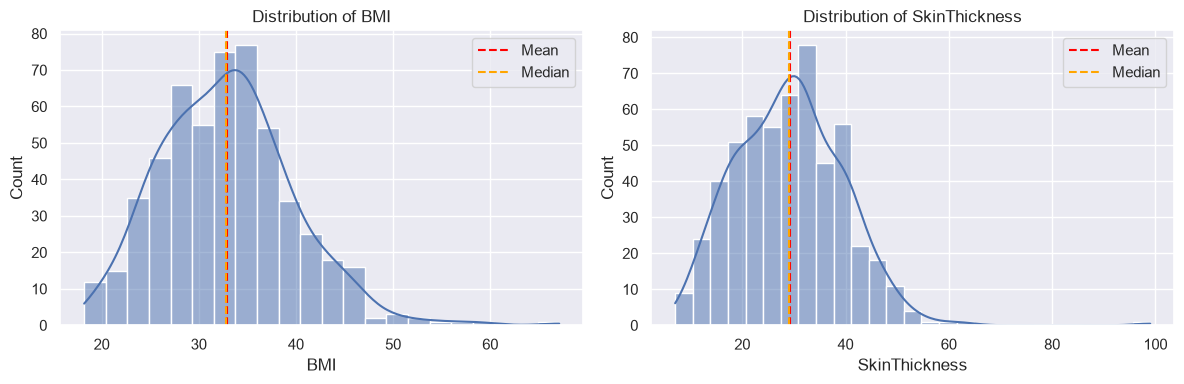

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for column, ax in zip(["BMI", "SkinThickness"], axes):
    sns.histplot(model_df[column], bins="auto", kde=True, ax=ax)
    ax.axvline(
        model_df[column].mean(),
        color="red",
        linestyle="--",
        label="Mean",
    )
    ax.axvline(
        model_df[column].median(),
        color="orange",
        linestyle="--",
        label="Median",
    )
    ax.set_title(f"Distribution of {column}")
    ax.legend()

plt.tight_layout()
plt.show()

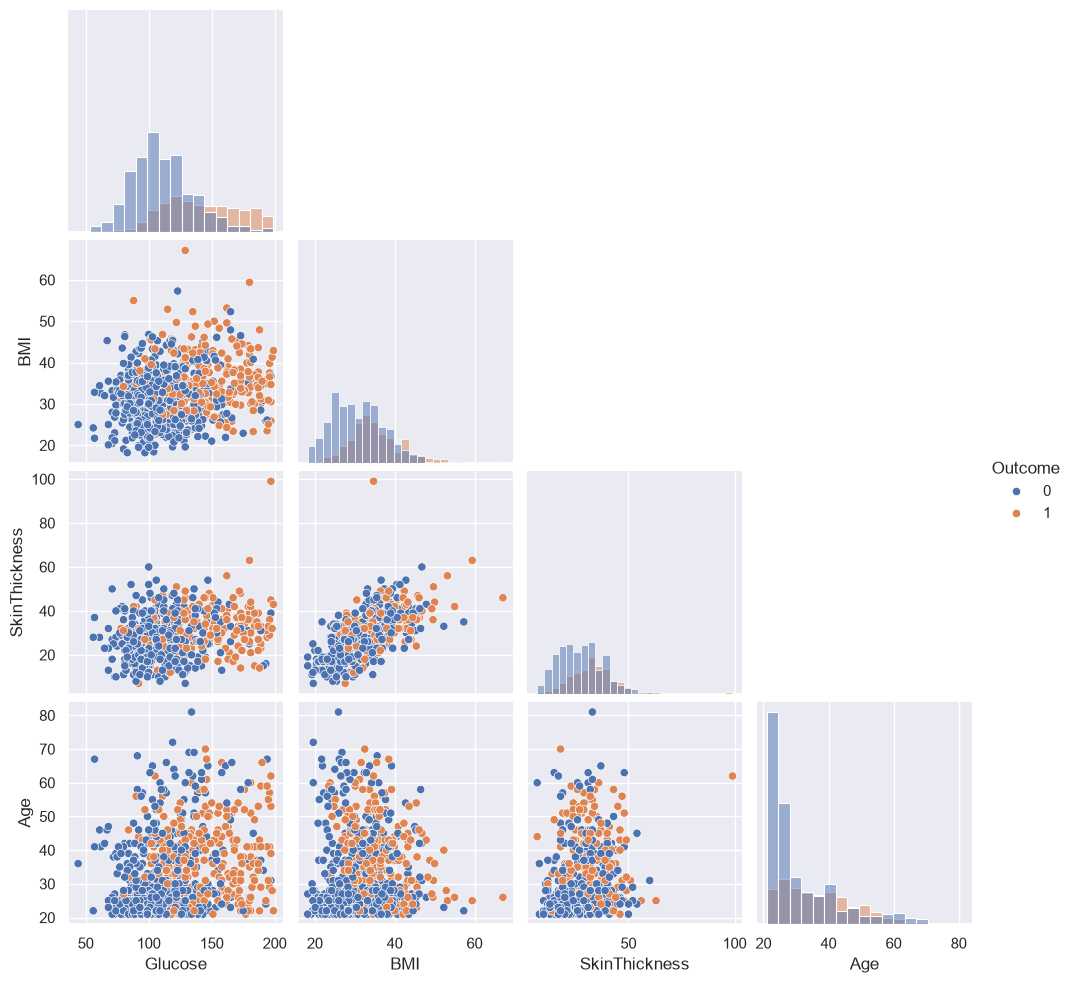

In [ ]:
pairplot_columns = ["Glucose","BMI","SkinThickness","Age","Outcome",]
sns.pairplot(clean_df[pairplot_columns],hue="Outcome",corner=True,diag_kind="hist",dropna=True,)
plt.show()

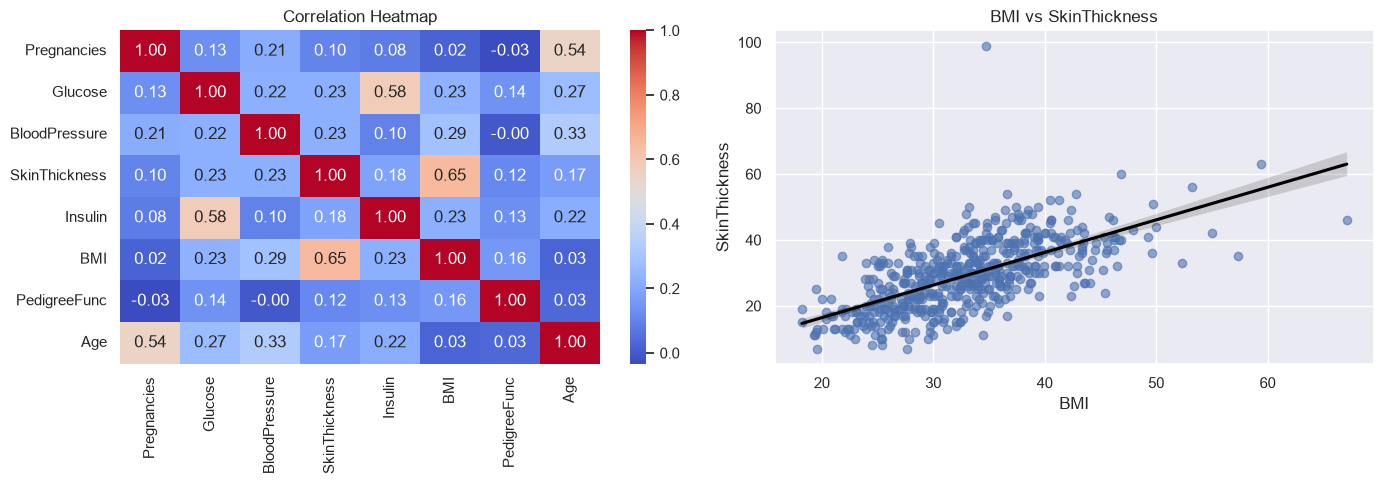

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
correlation_matrix = clean_df.iloc[:, :-1].corr()
sns.heatmap(correlation_matrix,cmap="coolwarm",annot=True,fmt=".2f",ax=axes[0],)
axes[0].set_title("Correlation Heatmap")
sns.regplot(data=model_df,x="BMI",y="SkinThickness",scatter_kws={"alpha": 0.6},line_kws={"color": "black"},ax=axes[1],)
axes[1].set_title("BMI vs SkinThickness")
plt.tight_layout()
plt.show()

## Outlier Diagnosis

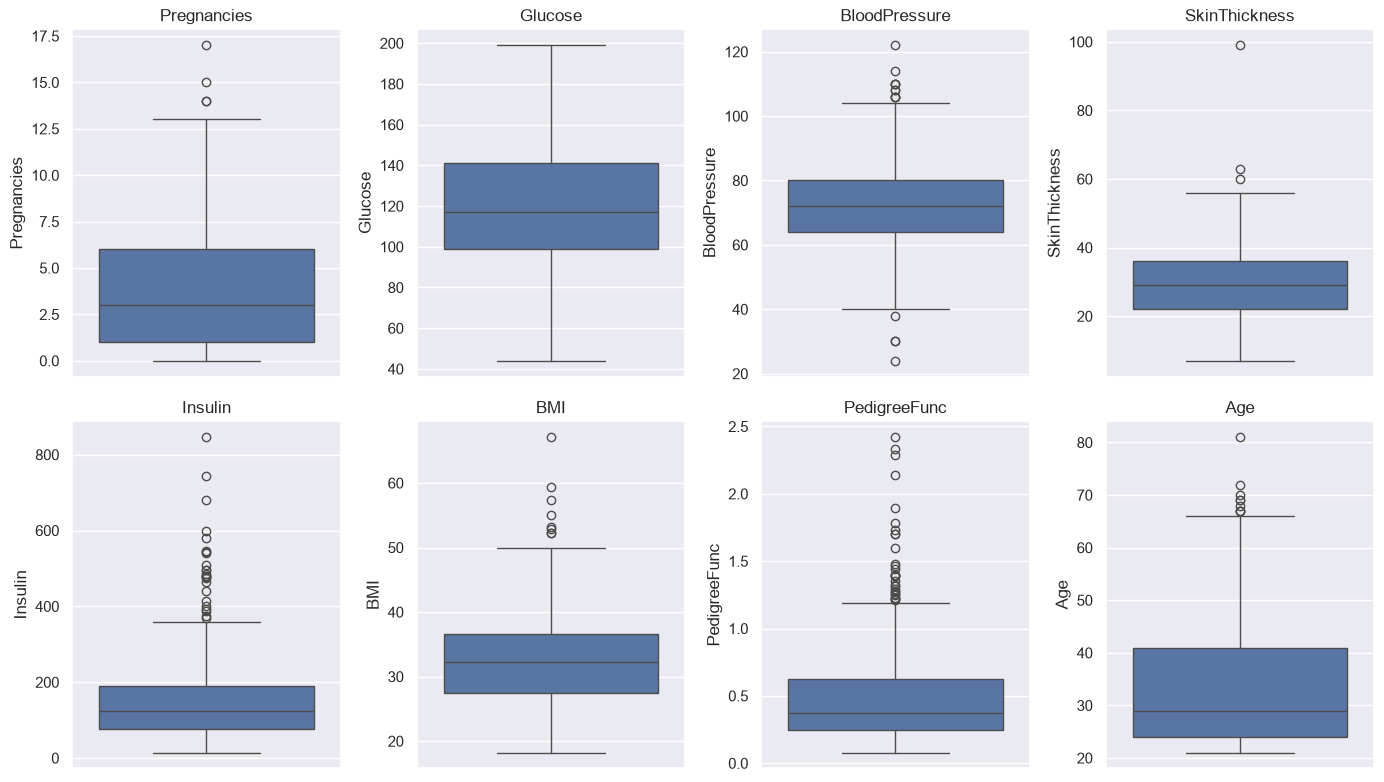

In [10]:
feature_columns = clean_df.columns[:-1]
fig, axes = plt.subplots(2, 4, figsize=(14, 8))

for column, ax in zip(feature_columns, axes.flatten()):
    sns.boxplot(data=clean_df, y=column, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

In [11]:
def iqr_outlier_summary(data, columns):
    rows = []

    for column in columns:
        values = data[column].dropna()
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_count = (
            (values < lower_bound) | (values > upper_bound)
        ).sum()

        rows.append(
            {
                "Feature": column,
                "Lower bound": lower_bound,
                "Upper bound": upper_bound,
                "Potential outliers": outlier_count,
            }
        )

    return pd.DataFrame(rows)


iqr_outlier_summary(model_df, ["BMI", "SkinThickness"]).round(2)

,Feature,Lower bound,Upper bound,Potential outliers
0,BMI,14.28,50.47,6
1,SkinThickness,1.00,57.00,3


The IQR rule is used here as a diagnostic tool. Potential outliers are not automatically deleted or replaced with the mean because extreme observations may still be valid patients. Any removal would require a documented clinical or data-quality reason.

## Linear Regression

We model **SkinThickness** as the dependent variable and **BMI** as the independent variable. The data is divided into 70% training and 30% testing observations. The same split is used for both versions of the model.

In [ ]:
X = model_df[["BMI"]]
y = model_df["SkinThickness"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42,)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print(f"Intercept: {lr_model.intercept_:.4f}")
print(f"BMI coefficient: {lr_model.coef_[0]:.4f}")

Intercept: -1.7190
BMI coefficient: 0.9336


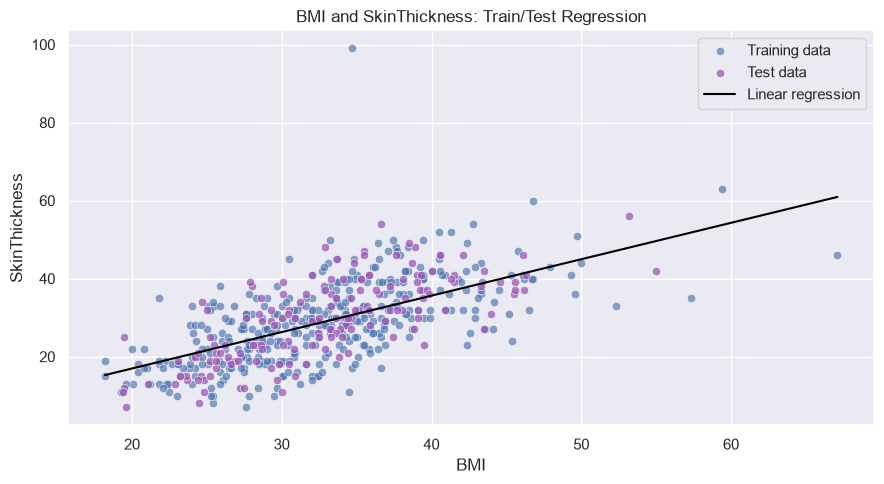

In [ ]:
line_data = pd.DataFrame(
    {
        "BMI": np.linspace(
            model_df["BMI"].min(),
            model_df["BMI"].max(),
            200,
        )
    }
)

plt.figure(figsize=(9, 5))
sns.scatterplot(x=X_train["BMI"],y=y_train,label="Training data",alpha=0.65,)
sns.scatterplot(x=X_test["BMI"],y=y_test,label="Test data",color="#9b59b6",alpha=0.75,)
plt.plot(line_data["BMI"],lr_model.predict(line_data),color="black",label="Linear regression",)
plt.xlabel("BMI")
plt.ylabel("SkinThickness")
plt.title("BMI and SkinThickness: Train/Test Regression")
plt.legend()
plt.tight_layout()
plt.show()

## Standardized Predictor

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_lr_model = LinearRegression()
scaled_lr_model.fit(X_train_scaled, y_train)
y_pred_scaled = scaled_lr_model.predict(X_test_scaled)

prediction_difference = np.max(np.abs(y_pred - y_pred_scaled))

print(f"Scaled intercept: {scaled_lr_model.intercept_:.4f}")
print(f"Scaled BMI coefficient: {scaled_lr_model.coef_[0]:.4f}")
print(f"Maximum prediction difference: {prediction_difference:.3e}")

Scaled intercept: 28.9496
Scaled BMI coefficient: 6.5014
Maximum prediction difference: 1.066e-14


The scaler is fitted only on the training predictor and is then applied to the test predictor. `SkinThickness` remains on its original scale. In simple ordinary least squares with an intercept, standardizing BMI changes the numerical coefficient but not the fitted predictions or model performance.

In [15]:
bmi_value = pd.DataFrame({"BMI": [65.0]})
predicted_skin_thickness = lr_model.predict(bmi_value)[0]

print(
    "Predicted SkinThickness for BMI = 65:",
    f"{predicted_skin_thickness:.2f}",
)
print(
    "Observed BMI range:",
    f"{model_df['BMI'].min():.1f} to {model_df['BMI'].max():.1f}",
)

Predicted SkinThickness for BMI = 65: 58.96
Observed BMI range: 18.2 to 67.1


## Evaluation Metrics

In [16]:
# AIC and BIC are calculated on the training data using OLS.
X_train_ols = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_ols).fit()

X_train_scaled_ols = sm.add_constant(X_train_scaled)
scaled_ols_model = sm.OLS(
    y_train.to_numpy(),
    X_train_scaled_ols,
).fit()


def regression_metrics(
    model_name,
    y_true,
    predictions,
    fitted_ols_model,
):
    mse = mean_squared_error(y_true, predictions)

    return {
        "Model": model_name,
        "Test MSE": mse,
        "Test RMSE": np.sqrt(mse),
        "Test MAE": mean_absolute_error(y_true, predictions),
        "Test R²": r2_score(y_true, predictions),
        "Train AIC": fitted_ols_model.aic,
        "Train BIC": fitted_ols_model.bic,
    }


metrics = pd.DataFrame(
    [
        regression_metrics(
            "Original BMI",
            y_test,
            y_pred,
            ols_model,
        ),
        regression_metrics(
            "Standardized BMI",
            y_test,
            y_pred_scaled,
            scaled_ols_model,
        ),
    ]
)

metrics.round(3)

,Model,Test MSE,Test RMSE,Test MAE,Test R²,Train AIC,Train BIC
0,Original BMI,53.116,7.288,5.874,0.505,2667.288,2675.152
1,Standardized BMI,53.116,7.288,5.874,0.505,2667.288,2675.152


MSE, RMSE and MAE describe prediction error on the test set, while test R² describes the proportion of test-set variation captured by the model. AIC and BIC are likelihood-based criteria for comparing models fitted to the same response data; lower values are preferred only when models are compared on the same sample and scale.

The two rows should be practically identical because scaling BMI does not create a different linear relationship. A low test R² would indicate that BMI alone is not sufficient to explain most of the variation in SkinThickness.

## Residual Diagnostics

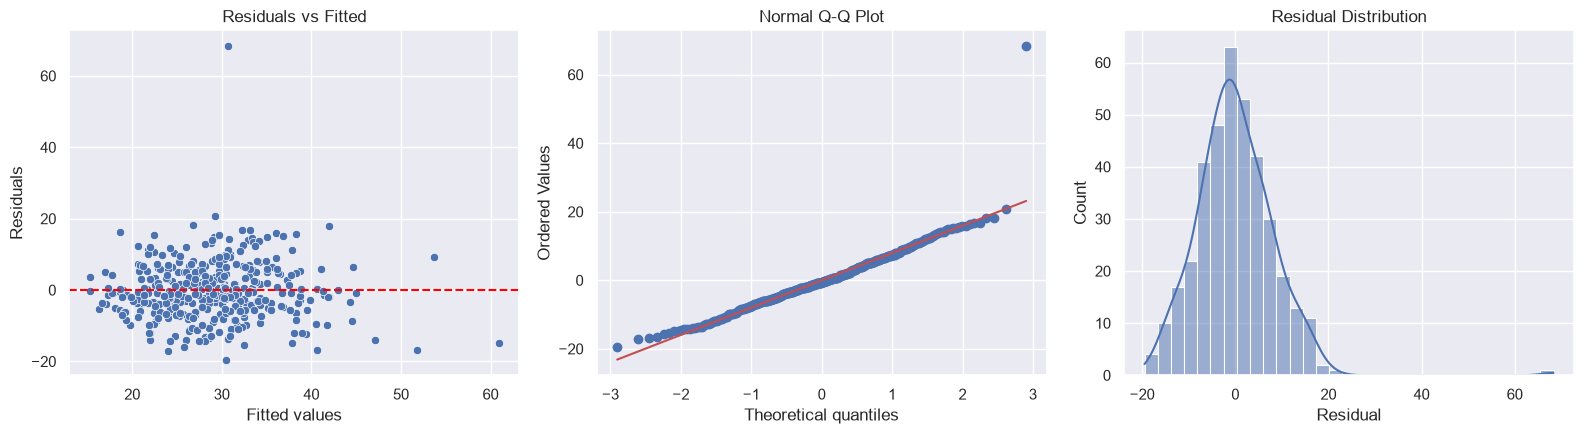

In [17]:
fitted_values = ols_model.fittedvalues
residuals = ols_model.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q Plot")

sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residual")

plt.tight_layout()
plt.show()

In [18]:
lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(
    residuals,
    ols_model.model.exog,
)

breusch_pagan_results = pd.Series(
    {
        "LM statistic": lm_stat,
        "LM p-value": lm_pvalue,
        "F statistic": f_stat,
        "F p-value": f_pvalue,
    },
    name="Breusch-Pagan test",
)

breusch_pagan_results.round(4)

LM statistic    1.4854
LM p-value      0.2229
F statistic     1.4834
F p-value       0.2240
Name: Breusch-Pagan test, dtype: float64

The residual-vs-fitted plot is used to inspect linearity and constant variance, while the Q-Q plot and histogram help assess residual normality. For the Breusch-Pagan test, a small p-value provides evidence against constant residual variance. These diagnostics should be interpreted together rather than from a single graph or test.

## Conclusion and Limitations

This experiment demonstrates a complete simple-regression workflow from raw-data auditing to model diagnostics. BMI may have a positive relationship with SkinThickness, but a one-predictor model is intentionally limited and should not be interpreted as a clinical tool.

Important limitations include missing clinical measurements represented by zeros, the use of complete BMI–SkinThickness pairs, possible non-linearity and heteroscedasticity, and the absence of other potentially relevant predictors. Future work could compare multiple regression, regularized models and tree-based regression under cross-validation.